**H-NMR Classification with Random Forest**

========================================

This notebook focuses on Random Forest classification of H-NMR spectra,
including hyperparameter tuning and model interpretation.

**Random Forest Hyperparameter Tuning**

After CNNs failed to learn meaningful patterns from the binned H-NMR spectra, we focused on optimizing Random Forest as the primary classification method.

**Approach**

- Baseline model: Random Forest with 200 trees, max_depth=20
- Grid Search: Systematic hyperparameter optimization using 5-fold cross-validation across 648 parameter combinations
- Parameters tuned: n_estimators (100-500), max_depth (10-30/None), min_samples_split (2-10), min_samples_leaf (1-4), max_features (sqrt/log2/None)

**Results**
- Improvement: +1.56% test accuracy

**Best Hyperparameters**

- n_estimators: 200
- max_depth: 25 (slightly deeper than baseline)
- max_features: 'log2' (more restrictive feature selection)
- min_samples_split: 2, min_samples_leaf: 1 (standard values)
- Best CV score: 69.3%

**Key Observations**

- Lipids are most distinctive with 86% recall, suggesting clear spectral signatures
- Heterocycles struggle with only 33% recall, frequently confused with other classes (especially Nitrogenous acids)
- 66.4% appears near optimal given the inherent class overlap observed in PCA analysis
- The modest improvement from tuning suggests the baseline was already reasonably configured

H-NMR CLASSIFICATION WITH RANDOM FOREST

[1] Loading preprocessed data...
Data shape: (847, 400)
Number of samples: 847
Number of features (bins): 400
Classes: ['Aromatics' 'Heterocycles & nucleotides' 'Lipids'
 'Nitrogenous & organic acids' 'Organic oxygen compounds']

Class distribution:
  Aromatics............................... 127 ( 15.0%)
  Heterocycles & nucleotides.............. 180 ( 21.3%)
  Lipids.................................. 189 ( 22.3%)
  Nitrogenous & organic acids............. 251 ( 29.6%)
  Organic oxygen compounds................ 100 ( 11.8%)

[2] Encoding labels...
Number of classes: 5
Class encoding: {'Aromatics': 0, 'Heterocycles & nucleotides': 1, 'Lipids': 2, 'Nitrogenous & organic acids': 3, 'Organic oxygen compounds': 4}

[3] Creating stratified train/val/test splits...
Train set: 592 samples (69.9%)
Val set:   127 samples (15.0%)
Test set:  128 samples (15.1%)

Class distribution in splits:
Train: {0: 89, 1: 126, 2: 132, 3: 175, 4: 70}
Val: {0: 19, 1: 27, 

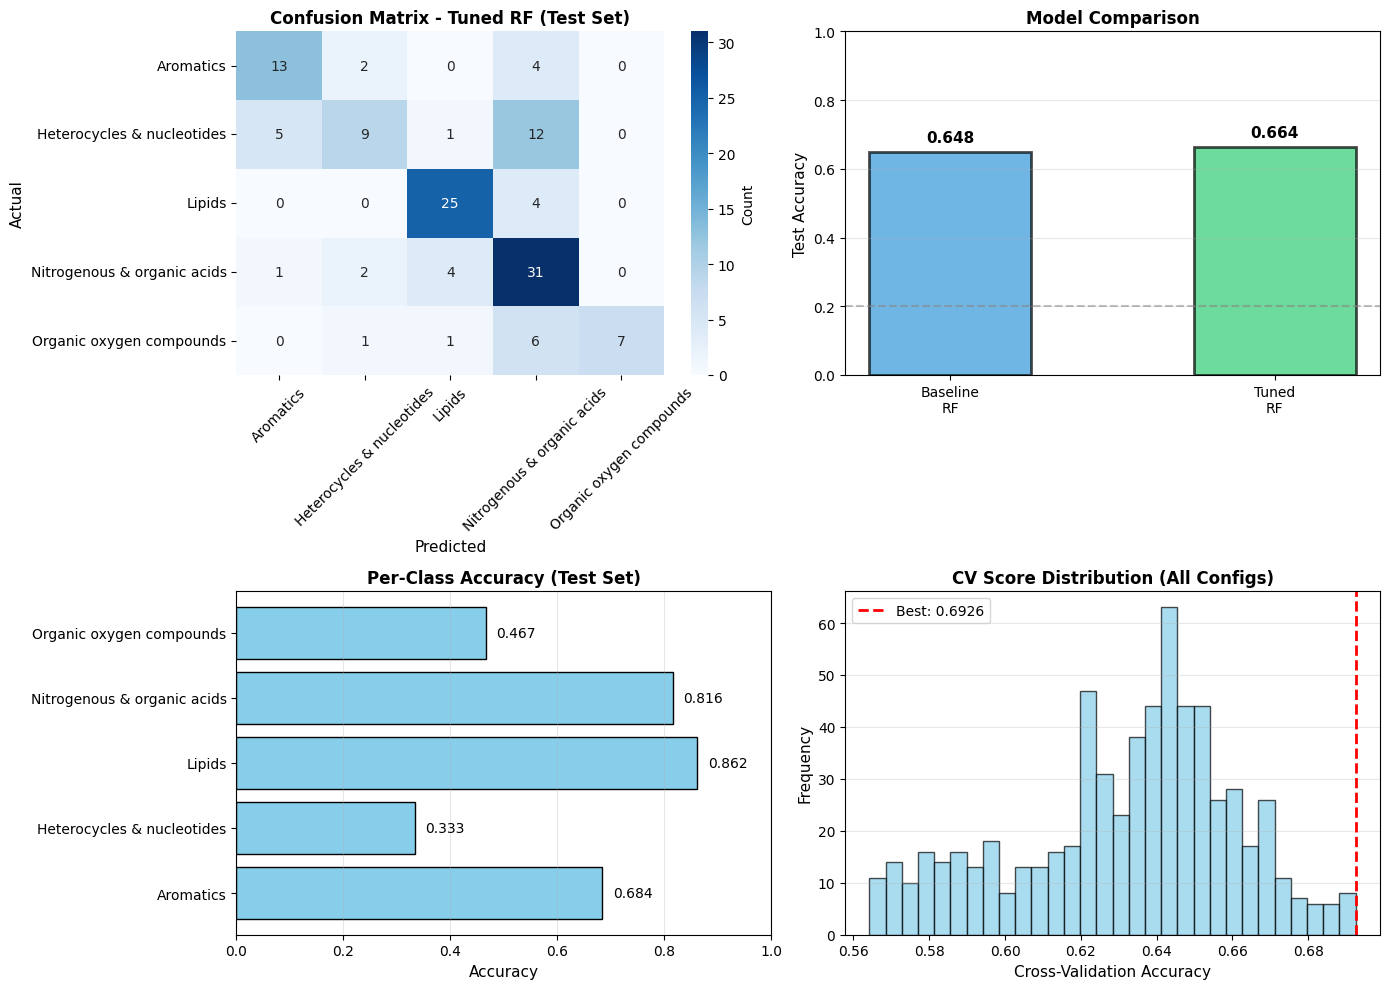


SUMMARY
Baseline RF test accuracy:  0.6484
Tuned RF test accuracy:     0.6641
Improvement:                +1.56%

Best hyperparameters: {'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, confusion_matrix, classification_report)

# Set random seed for reproducibility
np.random.seed(42)

print("="*60)
print("H-NMR CLASSIFICATION WITH RANDOM FOREST")
print("="*60)

# --- 1. LOAD PREPROCESSED DATA ---
print("\n[1] Loading preprocessed data...")
df = pd.read_csv("processed_data/nmr_features_with_groups.csv")

# Separate features and labels
X = df.iloc[:, 2:].values  # All bin columns (skip accession and group)
y = df['group'].values
accessions = df['accession'].values

print(f"Data shape: {X.shape}")
print(f"Number of samples: {len(X)}")
print(f"Number of features (bins): {X.shape[1]}")
print(f"Classes: {np.unique(y)}")

# Class distribution
print(f"\nClass distribution:")
for group in np.unique(y):
    count = (y == group).sum()
    pct = 100 * count / len(y)
    print(f"  {group:.<40} {count:>3} ({pct:>5.1f}%)")

# --- 2. ENCODE LABELS ---
print("\n[2] Encoding labels...")
le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(le.classes_)

print(f"Number of classes: {n_classes}")
print(f"Class encoding: {dict(zip(le.classes_, range(n_classes)))}")

# --- 3. TRAIN/VAL/TEST SPLIT ---
print("\n[3] Creating stratified train/val/test splits...")

# First split: 70% train, 30% temp (val+test)
X_train, X_temp, y_train, y_temp, acc_train, acc_temp = train_test_split(
    X, y_encoded, accessions, test_size=0.30, random_state=42, stratify=y_encoded
)

# Second split: split temp into 50/50 (15% val, 15% test)
X_val, X_test, y_val, y_test, acc_val, acc_test = train_test_split(
    X_temp, y_temp, acc_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train set: {X_train.shape[0]} samples ({100*X_train.shape[0]/len(X):.1f}%)")
print(f"Val set:   {X_val.shape[0]} samples ({100*X_val.shape[0]/len(X):.1f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({100*X_test.shape[0]/len(X):.1f}%)")

# Verify stratification
print("\nClass distribution in splits:")
for split_name, split_y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    unique, counts = np.unique(split_y, return_counts=True)
    print(f"{split_name}: {dict(zip(unique, counts))}")

# --- 4. BASELINE RANDOM FOREST ---
print("\n" + "="*60)
print("[4] BASELINE RANDOM FOREST")
print("="*60)

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

# Evaluate baseline
train_acc_baseline = rf_baseline.score(X_train, y_train)
val_acc_baseline = rf_baseline.score(X_val, y_val)
test_acc_baseline = rf_baseline.score(X_test, y_test)

print(f"\nBaseline RF Accuracy:")
print(f"  Train: {train_acc_baseline:.4f}")
print(f"  Val:   {val_acc_baseline:.4f}")
print(f"  Test:  {test_acc_baseline:.4f}")

# --- 5. HYPERPARAMETER TUNING ---
print("\n" + "="*60)
print("[5] HYPERPARAMETER TUNING WITH GRID SEARCH")
print("="*60)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

print(f"\nParameter grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

print(f"\nTotal combinations: {np.prod([len(v) for v in param_grid.values()])}")
print("Running GridSearchCV (this may take a few minutes)...")

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit grid search on training data
grid_search.fit(X_train, y_train)

print(f"\n✓ Grid search complete!")
print(f"\nBest parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation score: {grid_search.best_score_:.4f}")

# --- 6. EVALUATE TUNED MODEL ---
print("\n" + "="*60)
print("[6] EVALUATING TUNED MODEL")
print("="*60)

rf_tuned = grid_search.best_estimator_

# Predictions
y_train_pred = rf_tuned.predict(X_train)
y_val_pred = rf_tuned.predict(X_val)
y_test_pred = rf_tuned.predict(X_test)

# Calculate metrics
train_acc_tuned = accuracy_score(y_train, y_train_pred)
val_acc_tuned = accuracy_score(y_val, y_val_pred)
test_acc_tuned = accuracy_score(y_test, y_test_pred)

train_f1_tuned = f1_score(y_train, y_train_pred, average='weighted')
val_f1_tuned = f1_score(y_val, y_val_pred, average='weighted')
test_f1_tuned = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nTuned RF Accuracy:")
print(f"  Train: {train_acc_tuned:.4f}")
print(f"  Val:   {val_acc_tuned:.4f}")
print(f"  Test:  {test_acc_tuned:.4f}")

print(f"\nTuned RF F1-Score (weighted):")
print(f"  Train: {train_f1_tuned:.4f}")
print(f"  Val:   {val_f1_tuned:.4f}")
print(f"  Test:  {test_f1_tuned:.4f}")

print(f"\nImprovement over baseline:")
print(f"  Test accuracy: {test_acc_baseline:.4f} → {test_acc_tuned:.4f} ({100*(test_acc_tuned - test_acc_baseline):+.2f}%)")

# Classification report
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

# --- 7. VISUALIZATION ---
print("\n[7] Generating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_, 
            ax=axes[0, 0], cbar_kws={'label': 'Count'})
axes[0, 0].set_xlabel('Predicted', fontsize=11)
axes[0, 0].set_ylabel('Actual', fontsize=11)
axes[0, 0].set_title('Confusion Matrix - Tuned RF (Test Set)', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# Model comparison
models = ['Baseline\nRF', 'Tuned\nRF']
test_accuracies = [test_acc_baseline, test_acc_tuned]
colors = ['#3498db', '#2ecc71']
bars = axes[0, 1].bar(models, test_accuracies, color=colors, alpha=0.7,
                      edgecolor='black', linewidth=2, width=0.5)
axes[0, 1].set_ylabel('Test Accuracy', fontsize=11)
axes[0, 1].set_title('Model Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].axhline(y=0.2, color='gray', linestyle='--', alpha=0.5, label='Random (20%)')

for bar, acc in zip(bars, test_accuracies):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{acc:.3f}', ha='center', va='bottom', 
                    fontsize=11, fontweight='bold')

# Per-class accuracy
class_accuracies = []
for i, class_name in enumerate(le.classes_):
    mask = y_test == i
    if mask.sum() > 0:
        class_acc = (y_test_pred[mask] == i).sum() / mask.sum()
        class_accuracies.append(class_acc)
    else:
        class_accuracies.append(0)

axes[1, 0].barh(range(len(le.classes_)), class_accuracies, color='skyblue',
                edgecolor='black', linewidth=1)
axes[1, 0].set_yticks(range(len(le.classes_)))
axes[1, 0].set_yticklabels(le.classes_, fontsize=10)
axes[1, 0].set_xlabel('Accuracy', fontsize=11)
axes[1, 0].set_title('Per-Class Accuracy (Test Set)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].grid(True, alpha=0.3, axis='x')

for i, acc in enumerate(class_accuracies):
    axes[1, 0].text(acc + 0.02, i, f'{acc:.3f}', va='center', fontsize=10)

# Cross-validation scores distribution
cv_results = pd.DataFrame(grid_search.cv_results_)
top_10_indices = cv_results['rank_test_score'] <= 10
top_10_scores = cv_results.loc[top_10_indices, 'mean_test_score'].values

axes[1, 1].hist(cv_results['mean_test_score'], bins=30, color='skyblue',
                edgecolor='black', alpha=0.7)
axes[1, 1].axvline(grid_search.best_score_, color='red', linestyle='--',
                   linewidth=2, label=f'Best: {grid_search.best_score_:.4f}')
axes[1, 1].set_xlabel('Cross-Validation Accuracy', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('CV Score Distribution (All Configs)', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('RF_classifier_figures/rf_tuned_results.png', dpi=300, bbox_inches='tight')
print("✓ Saved: rf_tuned_results.png")
plt.show()

# --- 8. SUMMARY ---
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Baseline RF test accuracy:  {test_acc_baseline:.4f}")
print(f"Tuned RF test accuracy:     {test_acc_tuned:.4f}")
print(f"Improvement:                {100*(test_acc_tuned - test_acc_baseline):+.2f}%")
print(f"\nBest hyperparameters: {grid_search.best_params_}")
print("="*60)

**Save model**

This script:
1. Saves the trained Random Forest model
2. Saves preprocessing parameters (normalization stats)

In [7]:
"""
Model Saving
============
Save the trained Random Forest model and preprocessing parameters for deployment.
"""

import pickle
import json
import numpy as np
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Recalculate normalization parameters from training data
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8

# --- 1. SAVE THE TRAINED MODEL ---
print("="*60)
print("SAVING TRAINED MODEL")
print("="*60)

# Save the model using pickle
model_filename = 'models/rf_tuned_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(rf_tuned, f)
print(f"✓ Saved model to: {model_filename}")

# Save the label encoder
encoder_filename = 'models/label_encoder.pkl'
with open(encoder_filename, 'wb') as f:
    pickle.dump(le, f)
print(f"✓ Saved label encoder to: {encoder_filename}")

# --- 2. SAVE PREPROCESSING PARAMETERS ---
preprocessing_params = {
    'ppm_min': 0.0,
    'ppm_max': 10.0,
    'n_bins': 400,
    'normalization_mean': mean.tolist(),
    'normalization_std': std.tolist(),
    'bin_edges': np.linspace(0.0, 10.0, 401).tolist()
}

params_filename = 'models/preprocessing_params.json'
with open(params_filename, 'w') as f:
    json.dump(preprocessing_params, f, indent=2)
print(f"✓ Saved preprocessing parameters to: {params_filename}")

print("\nFiles saved successfully!")
print("These files are needed for deployment:")
print(f"  1. {model_filename} - Trained Random Forest model")
print(f"  2. {encoder_filename} - Label encoder for class names")
print(f"  3. {params_filename} - Preprocessing parameters")
print("="*60)

SAVING TRAINED MODEL
✓ Saved model to: models/rf_tuned_model.pkl
✓ Saved label encoder to: models/label_encoder.pkl
✓ Saved preprocessing parameters to: models/preprocessing_params.json

Files saved successfully!
These files are needed for deployment:
  1. models/rf_tuned_model.pkl - Trained Random Forest model
  2. models/label_encoder.pkl - Label encoder for class names
  3. models/preprocessing_params.json - Preprocessing parameters
